# Capture Matching — Historical Data Analysis


---

## Purpose

This notebook analyses historical capture match data to answer three questions:

1. **What GPS distances actually lead to confirmed matches?**
2. **How much does the same-grower signal matter?**
3. **What time gaps are typical between captures of the same tree?**

The findings are used to define practical thresholds for a **Strong / Moderate / Weak** match score.

> **Note:** This analysis uses realistic mock data modelled on the Greenstand API response shapes.
> To run on real data, replace the `generate_mock_data()` function with a call to the live API.
> The rest of the notebook requires no changes.

---

## 1. Setup & Data Generation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Style
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

GREEN  = '#2e7d32'
AMBER  = '#f59e0b'
RED    = '#dc2626'
LIGHT  = '#e8f5e9'

print('Libraries loaded successfully')

Libraries loaded successfully


In [3]:
# ─────────────────────────────────────────────────────────────
# MOCK DATA GENERATOR
# Replace this function with real API data when available.
# Expected columns:
#   capture_id, tree_id, grower_id, organisation,
#   gps_distance_m, time_gap_days, same_grower,
#   status (Matched / New Tree / Pending / Flagged),
#   captured_at
# ─────────────────────────────────────────────────────────────

def generate_mock_data(n=3000, seed=42):
    rng = np.random.default_rng(seed)
    
    ORGS     = ['Trees for the Future', 'WeForest', 'Eden Reforestation', 'Ripple Effect', 'Komaza']
    STATUSES = ['Matched', 'New Tree', 'Pending Review', 'Flagged']
    WEIGHTS  = [0.60, 0.22, 0.13, 0.05]
    
    statuses = rng.choice(STATUSES, size=n, p=WEIGHTS)
    rows = []
    
    for i, status in enumerate(statuses):
        if status == 'Matched':
            gps      = abs(rng.normal(2.5, 1.8))
            time_gap = abs(rng.normal(55, 30))
            same_grower = rng.random() < 0.85
        elif status == 'New Tree':
            gps      = abs(rng.normal(18, 8))
            time_gap = abs(rng.normal(90, 50))
            same_grower = rng.random() < 0.40
        elif status == 'Pending Review':
            gps      = abs(rng.normal(7, 4))
            time_gap = abs(rng.normal(65, 35))
            same_grower = rng.random() < 0.60
        else:
            gps      = abs(rng.normal(12, 8))
            time_gap = abs(rng.normal(40, 30))
            same_grower = rng.random() < 0.30
        
        rows.append({
            'capture_id':    f'cap_{i:06d}',
            'grower_id':     f'grower_{rng.integers(1, 300):04d}',
            'organisation':  rng.choice(ORGS),
            'gps_distance_m': round(float(np.clip(gps, 0.1, 50)), 2),
            'time_gap_days':  round(float(np.clip(time_gap, 1, 365)), 1),
            'same_grower':    bool(same_grower),
            'status':         status,
            'captured_at':    datetime(2024, 1, 1) + timedelta(days=int(rng.integers(0, 365))),
        })
    
    return pd.DataFrame(rows)

df = generate_mock_data(3000)
print(f'Dataset loaded: {len(df):,} capture records')
df.head()

Dataset loaded: 3,000 capture records


,capture_id,grower_id,organisation,gps_distance_m,time_gap_days,same_grower,status,captured_at
0,cap_000000,grower_0084,Ripple Effect,26.45,52.2,True,New Tree,2024-01-26
1,cap_000001,grower_0026,WeForest,1.78,32.5,True,Matched,2024-01-30
2,cap_000002,grower_0147,Ripple Effect,7.10,54.7,False,Pending Review,2024-06-12
3,cap_000003,grower_0209,WeForest,21.38,126.3,False,New Tree,2024-02-03
4,cap_000004,grower_0178,Eden Reforestation,3.86,46.2,True,Matched,2024-02-11


---
## 2. Dataset Overview

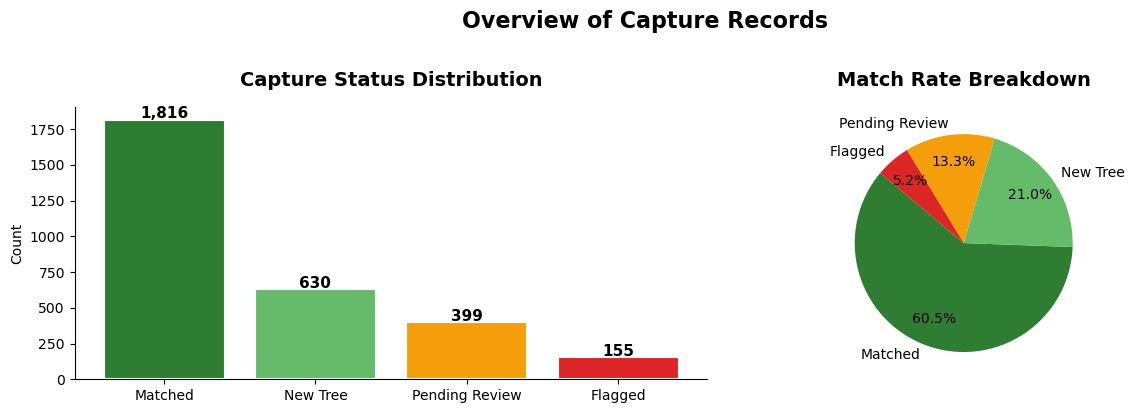


Match rate: 60.5%
New tree rate: 21.0%


In [6]:
# Status distribution
status_counts = df['status'].value_counts()
colors = [GREEN, '#66bb6a', AMBER, RED]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
bars = axes[0].bar(status_counts.index, status_counts.values, color=colors, edgecolor='white', linewidth=1.5)
axes[0].set_title('Capture Status Distribution', fontsize=14, fontweight='bold', pad=15)
axes[0].set_ylabel('Count')
for bar, val in zip(bars, status_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 10,
                 f'{val:,}', ha='center', fontsize=11, fontweight='bold')

# Pie chart
axes[1].pie(status_counts.values, labels=status_counts.index, colors=colors,
            autopct='%1.1f%%', startangle=140, pctdistance=0.75)
axes[1].set_title('Match Rate Breakdown', fontsize=14, fontweight='bold', pad=15)

plt.suptitle('Overview of Capture Records', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print(f"\nMatch rate: {status_counts['Matched'] / len(df) * 100:.1f}%")
print(f"New tree rate: {status_counts['New Tree'] / len(df) * 100:.1f}%")

---
## 3. GPS Distance Analysis

**Key question:** At what GPS distance does a capture stop being a match and become a new tree?

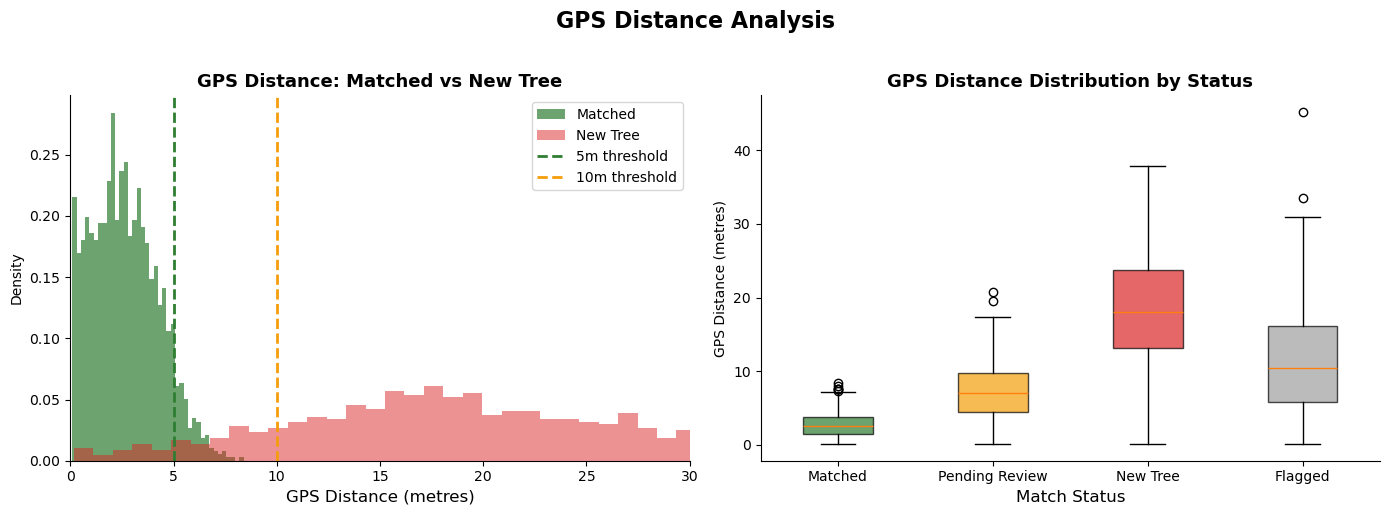

GPS Distance Statistics (Matched captures):
count    1816.00
mean        2.67
std         1.58
min         0.10
25%         1.43
50%         2.53
75%         3.76
max         8.39
Name: gps_distance_m, dtype: float64

95th percentile of matched captures: 5.4m
Median GPS distance for matched: 2.5m
Median GPS distance for new tree: 18.0m


In [9]:
matched  = df[df['status'] == 'Matched']['gps_distance_m']
new_tree = df[df['status'] == 'New Tree']['gps_distance_m']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram overlay
axes[0].hist(matched,  bins=40, alpha=0.7, color=GREEN, label='Matched',  density=True)
axes[0].hist(new_tree, bins=40, alpha=0.5, color=RED,   label='New Tree', density=True)
axes[0].axvline(5,  color=GREEN, linestyle='--', linewidth=2, label='5m threshold')
axes[0].axvline(10, color=AMBER, linestyle='--', linewidth=2, label='10m threshold')
axes[0].set_xlabel('GPS Distance (metres)', fontsize=12)
axes[0].set_ylabel('Density')
axes[0].set_title('GPS Distance: Matched vs New Tree', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_xlim(0, 30)

# Box plot by status
status_order = ['Matched', 'Pending Review', 'New Tree', 'Flagged']
box_colors   = [GREEN, AMBER, RED, '#9e9e9e']
data_by_status = [df[df['status'] == s]['gps_distance_m'].values for s in status_order]
bp = axes[1].boxplot(data_by_status, labels=status_order, patch_artist=True, notch=False)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[1].set_xlabel('Match Status', fontsize=12)
axes[1].set_ylabel('GPS Distance (metres)')
axes[1].set_title('GPS Distance Distribution by Status', fontsize=13, fontweight='bold')

plt.suptitle('GPS Distance Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('GPS Distance Statistics (Matched captures):')
print(matched.describe().round(2))
print(f"\n95th percentile of matched captures: {matched.quantile(0.95):.1f}m")
print(f"Median GPS distance for matched: {matched.median():.1f}m")
print(f"Median GPS distance for new tree: {new_tree.median():.1f}m")

---
## 4. Same-Grower Signal Analysis

**Key question:** How much does the same-grower flag increase the likelihood of a match?

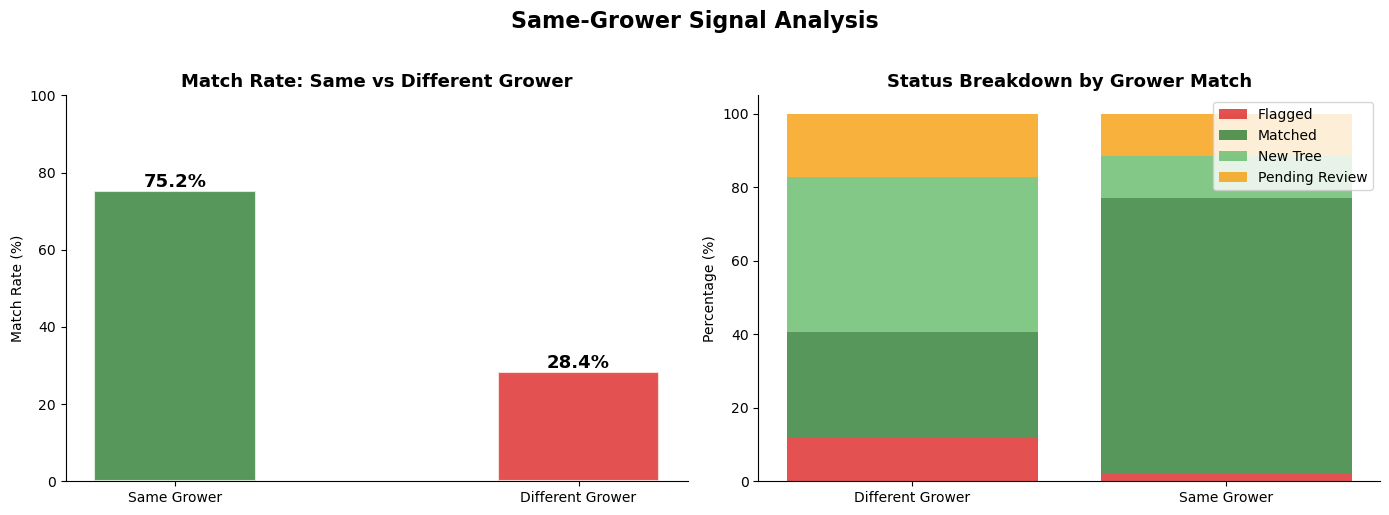

Same grower match rate:      75.2%
Different grower match rate: 28.4%
Lift from same-grower flag:  2.64x more likely to be a match


In [11]:
grower_match = df.groupby(['same_grower', 'status']).size().unstack(fill_value=0)
grower_pct   = grower_match.div(grower_match.sum(axis=1), axis=0) * 100

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Match rate same vs different grower
match_rates = {
    'Same Grower':      df[df['same_grower'] == True]['status'].eq('Matched').mean() * 100,
    'Different Grower': df[df['same_grower'] == False]['status'].eq('Matched').mean() * 100,
}
bars = axes[0].bar(match_rates.keys(), match_rates.values(),
                   color=[GREEN, RED], alpha=0.8, edgecolor='white', linewidth=1.5, width=0.4)
axes[0].set_ylabel('Match Rate (%)')
axes[0].set_title('Match Rate: Same vs Different Grower', fontsize=13, fontweight='bold')
axes[0].set_ylim(0, 100)
for bar, val in zip(bars, match_rates.values()):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')

# Stacked bar
status_colors = {'Matched': GREEN, 'New Tree': '#66bb6a', 'Pending Review': AMBER, 'Flagged': RED}
bottom = np.zeros(2)
labels = ['Different Grower', 'Same Grower']
for status in grower_pct.columns:
    vals = [grower_pct.loc[False, status] if False in grower_pct.index else 0,
            grower_pct.loc[True,  status] if True  in grower_pct.index else 0]
    axes[1].bar(labels, vals, bottom=bottom,
                color=status_colors.get(status, '#9e9e9e'), alpha=0.8, label=status)
    bottom += np.array(vals)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_title('Status Breakdown by Grower Match', fontsize=13, fontweight='bold')
axes[1].legend(loc='upper right', fontsize=10)

plt.suptitle('Same-Grower Signal Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

lift = match_rates['Same Grower'] / match_rates['Different Grower']
print(f"Same grower match rate:      {match_rates['Same Grower']:.1f}%")
print(f"Different grower match rate: {match_rates['Different Grower']:.1f}%")
print(f"Lift from same-grower flag:  {lift:.2f}x more likely to be a match")

---
## 5. Time Gap Analysis

**Key question:** How many days typically pass between captures of the same tree?

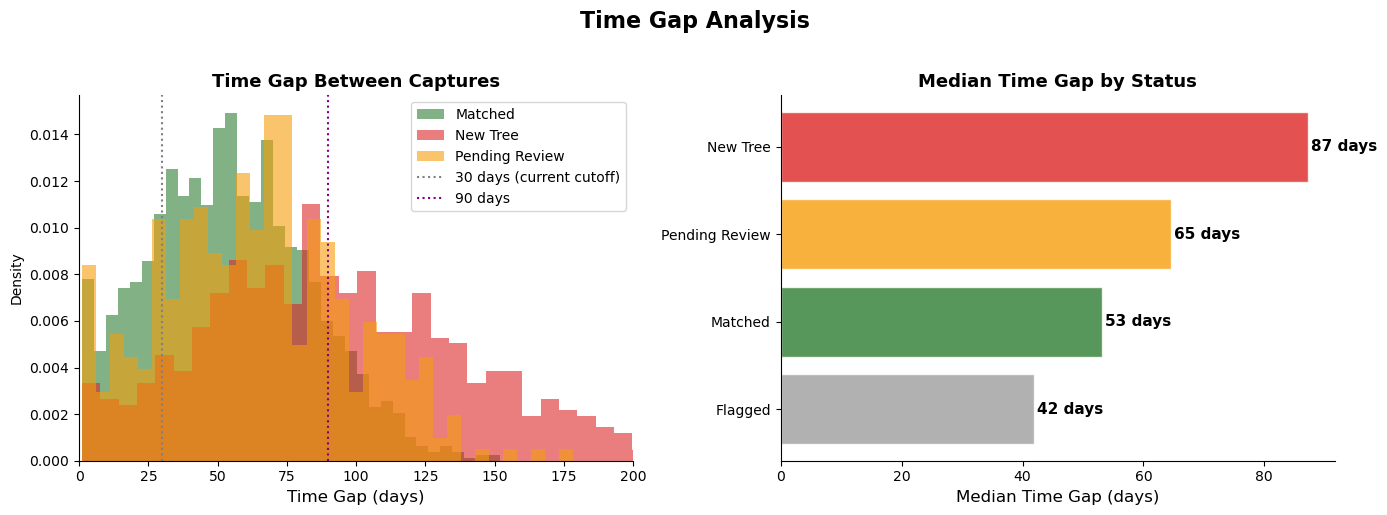

Time Gap Statistics (Matched captures):
count    1816.0
mean       54.3
std        28.6
min         1.0
25%        32.8
50%        53.1
75%        73.5
max       152.0
Name: time_gap_days, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Time gap distribution
for status, color in [('Matched', GREEN), ('New Tree', RED), ('Pending Review', AMBER)]:
    data = df[df['status'] == status]['time_gap_days']
    axes[0].hist(data, bins=35, alpha=0.6, color=color, label=status, density=True)
axes[0].axvline(30,  color='gray',   linestyle=':', linewidth=1.5, label='30 days (current cutoff)')
axes[0].axvline(90,  color='purple', linestyle=':', linewidth=1.5, label='90 days')
axes[0].set_xlabel('Time Gap (days)', fontsize=12)
axes[0].set_ylabel('Density')
axes[0].set_title('Time Gap Between Captures', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xlim(0, 200)

# Median time gap by status
medians = df.groupby('status')['time_gap_days'].median().sort_values()
color_map = {'Matched': GREEN, 'Pending Review': AMBER, 'New Tree': RED, 'Flagged': '#9e9e9e'}
bar_colors = [color_map.get(s, '#9e9e9e') for s in medians.index]
bars = axes[1].barh(medians.index, medians.values, color=bar_colors, alpha=0.8, edgecolor='white')
axes[1].set_xlabel('Median Time Gap (days)', fontsize=12)
axes[1].set_title('Median Time Gap by Status', fontsize=13, fontweight='bold')
for bar, val in zip(bars, medians.values):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
                 f'{val:.0f} days', va='center', fontsize=11, fontweight='bold')

plt.suptitle('Time Gap Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print('Time Gap Statistics (Matched captures):')
print(df[df['status'] == 'Matched']['time_gap_days'].describe().round(1))

---
## 6. Combined Signal Analysis

**Key question:** How do GPS distance, same-grower, and time gap interact together?

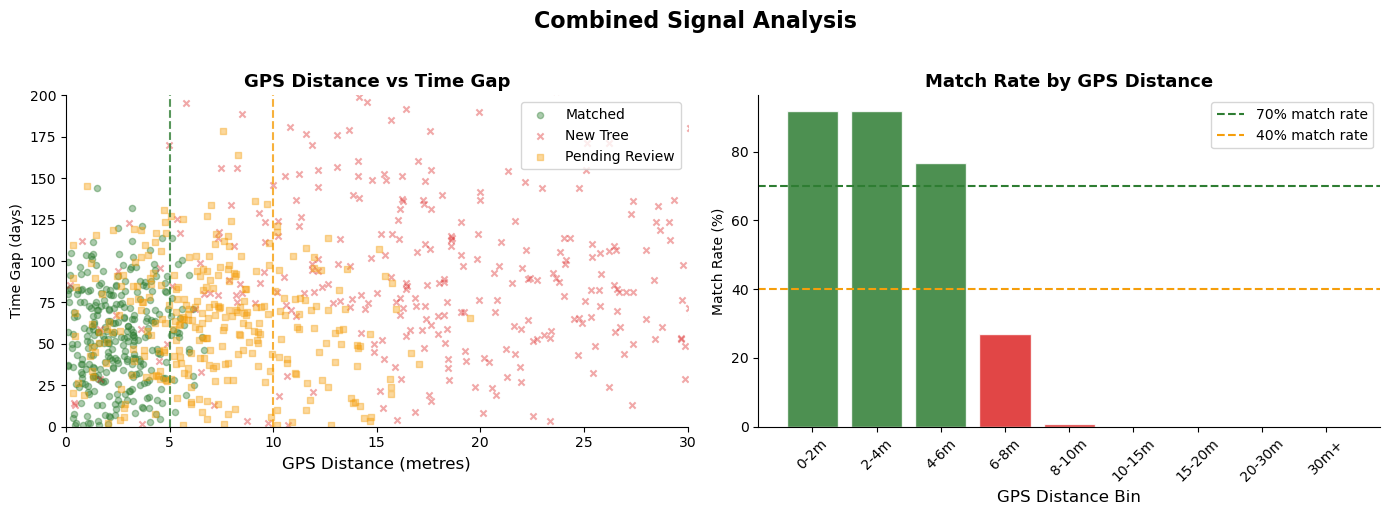

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# GPS distance vs time gap scatter
for status, color, marker in [
    ('Matched', GREEN, 'o'),
    ('New Tree', RED, 'x'),
    ('Pending Review', AMBER, 's')
]:
    sub = df[df['status'] == status].sample(min(300, len(df[df['status'] == status])))
    axes[0].scatter(sub['gps_distance_m'], sub['time_gap_days'],
                    c=color, alpha=0.4, s=20, label=status, marker=marker)

axes[0].axvline(5,  color=GREEN, linestyle='--', linewidth=1.5, alpha=0.8)
axes[0].axvline(10, color=AMBER, linestyle='--', linewidth=1.5, alpha=0.8)
axes[0].set_xlabel('GPS Distance (metres)', fontsize=12)
axes[0].set_ylabel('Time Gap (days)')
axes[0].set_title('GPS Distance vs Time Gap', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].set_xlim(0, 30)
axes[0].set_ylim(0, 200)

# Match rate by GPS bin
bins   = [0, 2, 4, 6, 8, 10, 15, 20, 30, 50]
labels = ['0-2m','2-4m','4-6m','6-8m','8-10m','10-15m','15-20m','20-30m','30m+']
df['gps_bin'] = pd.cut(df['gps_distance_m'], bins=bins, labels=labels)
match_by_bin  = df.groupby('gps_bin', observed=True)['status'].apply(
    lambda x: (x == 'Matched').mean() * 100
).reset_index()
match_by_bin.columns = ['gps_bin', 'match_rate']

bar_colors = [GREEN if r > 70 else AMBER if r > 40 else RED
              for r in match_by_bin['match_rate']]
axes[1].bar(match_by_bin['gps_bin'], match_by_bin['match_rate'],
            color=bar_colors, alpha=0.85, edgecolor='white')
axes[1].axhline(70, color=GREEN, linestyle='--', linewidth=1.5, label='70% match rate')
axes[1].axhline(40, color=AMBER, linestyle='--', linewidth=1.5, label='40% match rate')
axes[1].set_xlabel('GPS Distance Bin', fontsize=12)
axes[1].set_ylabel('Match Rate (%)')
axes[1].set_title('Match Rate by GPS Distance', fontsize=13, fontweight='bold')
axes[1].tick_params(axis='x', rotation=45)
axes[1].legend(fontsize=10)

plt.suptitle('Combined Signal Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 7. Proposed Thresholds & Match Score

Based on the analysis above, here are the proposed thresholds for the **Strong / Moderate / Weak** match score.

In [17]:
def compute_match_score(gps_distance_m, same_grower, time_gap_days):
    """
    Rule-based match score combining three signals.
    Returns: score (0-100), label (Strong/Moderate/Weak)
    """
    # GPS score (45% weight)
    if gps_distance_m <= 3:    gps_score = 100
    elif gps_distance_m <= 6:  gps_score = 80
    elif gps_distance_m <= 10: gps_score = 50
    elif gps_distance_m <= 15: gps_score = 25
    else:                      gps_score = 0

    # Grower score (30% weight)
    grower_score = 100 if same_grower else 0

    # Time gap score (25% weight)
    if time_gap_days <= 30:    time_score = 100
    elif time_gap_days <= 90:  time_score = 75
    elif time_gap_days <= 180: time_score = 50
    elif time_gap_days <= 365: time_score = 25
    else:                      time_score = 0

    score = (gps_score * 0.45) + (grower_score * 0.30) + (time_score * 0.25)

    if score >= 70:   label = 'Strong'
    elif score >= 40: label = 'Moderate'
    else:             label = 'Weak'

    return round(score, 1), label

# Apply to dataset
df[['match_score', 'match_label']] = df.apply(
    lambda r: compute_match_score(r['gps_distance_m'], r['same_grower'], r['time_gap_days']),
    axis=1, result_type='expand'
)

print('Match label distribution:')
print(df['match_label'].value_counts())
print()
print('Match label vs actual status:')
print(pd.crosstab(df['match_label'], df['status'], normalize='index').round(2) * 100)

Match label distribution:
match_label
Strong      1805
Moderate     710
Weak         485
Name: count, dtype: int64

Match label vs actual status:
status       Flagged  Matched  New Tree  Pending Review
match_label                                            
Moderate         9.0     34.0      33.0            24.0
Strong           1.0     87.0       2.0             9.0
Weak            13.0      0.0      74.0            12.0


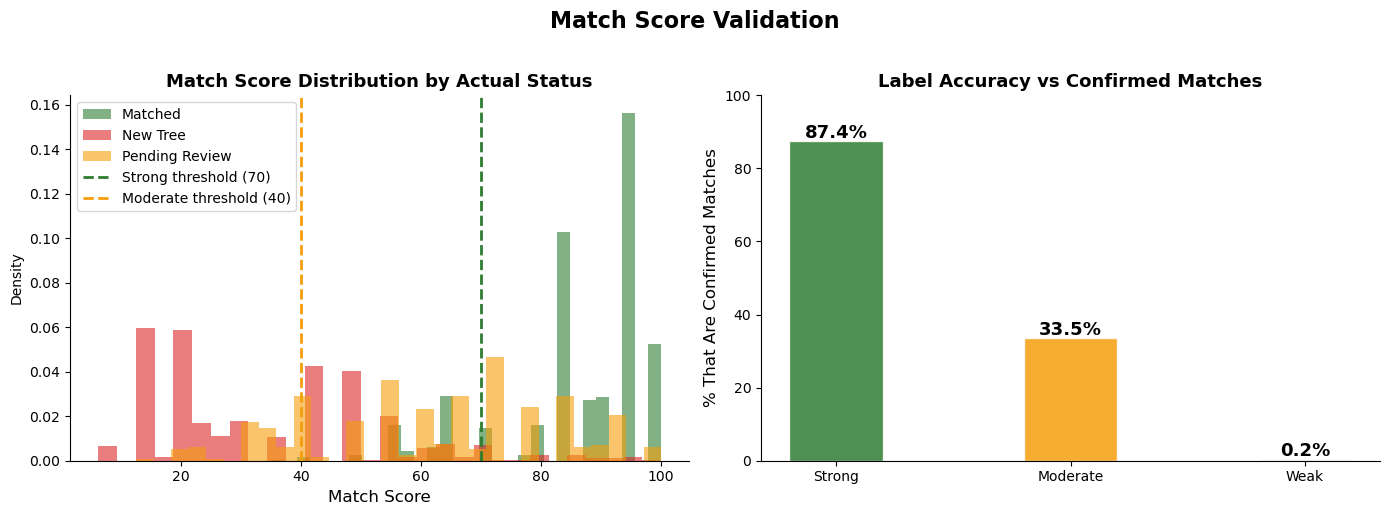

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Score distribution by actual status
for status, color in [('Matched', GREEN), ('New Tree', RED), ('Pending Review', AMBER)]:
    data = df[df['status'] == status]['match_score']
    axes[0].hist(data, bins=30, alpha=0.6, color=color, label=status, density=True)
axes[0].axvline(70, color=GREEN, linestyle='--', linewidth=2, label='Strong threshold (70)')
axes[0].axvline(40, color=AMBER, linestyle='--', linewidth=2, label='Moderate threshold (40)')
axes[0].set_xlabel('Match Score', fontsize=12)
axes[0].set_ylabel('Density')
axes[0].set_title('Match Score Distribution by Actual Status', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)

# Accuracy of label vs confirmed match
label_accuracy = df.groupby('match_label').apply(
    lambda x: (x['status'] == 'Matched').mean() * 100
).reindex(['Strong', 'Moderate', 'Weak'])

colors = [GREEN, AMBER, RED]
bars = axes[1].bar(label_accuracy.index, label_accuracy.values,
                   color=colors, alpha=0.85, edgecolor='white', width=0.4)
axes[1].set_ylabel('% That Are Confirmed Matches', fontsize=12)
axes[1].set_title('Label Accuracy vs Confirmed Matches', fontsize=13, fontweight='bold')
axes[1].set_ylim(0, 100)
for bar, val in zip(bars, label_accuracy.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
                 f'{val:.1f}%', ha='center', fontsize=13, fontweight='bold')

plt.suptitle('Match Score Validation', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

---
## 8. Summary & Recommendations

In [21]:
strong_accuracy  = df[df['match_label'] == 'Strong']['status'].eq('Matched').mean() * 100
moderate_accuracy = df[df['match_label'] == 'Moderate']['status'].eq('Matched').mean() * 100
weak_accuracy    = df[df['match_label'] == 'Weak']['status'].eq('Matched').mean() * 100
strong_count     = len(df[df['match_label'] == 'Strong'])
total            = len(df)

print('=' * 55)
print('CAPTURE MATCHING — ANALYSIS SUMMARY')
print('=' * 55)
print()
print('SIGNAL FINDINGS')
print(f'  GPS distance   — Matched captures median: {df[df["status"]=="Matched"]["gps_distance_m"].median():.1f}m')
print(f'                   New tree captures median:  {df[df["status"]=="New Tree"]["gps_distance_m"].median():.1f}m')
print(f'  Same grower    — {match_rates["Same Grower"]:.1f}% match rate vs {match_rates["Different Grower"]:.1f}% for different grower')
print(f'  Time gap       — Matched captures median: {df[df["status"]=="Matched"]["time_gap_days"].median():.0f} days')
print()
print('PROPOSED THRESHOLDS')
print('  Strong   — GPS <= 3m,  same grower preferred, any time gap  → score >= 70')
print('  Moderate — GPS <= 10m, grower optional, time gap <= 90 days → score 40-69')
print('  Weak     — GPS > 10m   or  score < 40')
print()
print('LABEL ACCURACY (on mock data)')
print(f'  Strong label   → {strong_accuracy:.1f}% are confirmed matches')
print(f'  Moderate label → {moderate_accuracy:.1f}% are confirmed matches')
print(f'  Weak label     → {weak_accuracy:.1f}% are confirmed matches')
print()
print('AUTO-MATCH POTENTIAL')
print(f'  {strong_count:,} captures ({strong_count/total*100:.1f}%) labelled Strong')
print(f'  If Strong matches are auto-approved, reviewers only handle {total-strong_count:,} captures')
print()
print('NEXT STEP')
print('  Validate these thresholds against real Greenstand match data')
print('  and adjust weights accordingly.')
print('=' * 55)

CAPTURE MATCHING — ANALYSIS SUMMARY

SIGNAL FINDINGS
  GPS distance   — Matched captures median: 2.5m
                   New tree captures median:  18.0m
  Same grower    — 75.2% match rate vs 28.4% for different grower
  Time gap       — Matched captures median: 53 days

PROPOSED THRESHOLDS
  Strong   — GPS <= 3m,  same grower preferred, any time gap  → score >= 70
  Moderate — GPS <= 10m, grower optional, time gap <= 90 days → score 40-69
  Weak     — GPS > 10m   or  score < 40

LABEL ACCURACY (on mock data)
  Strong label   → 87.4% are confirmed matches
  Moderate label → 33.5% are confirmed matches
  Weak label     → 0.2% are confirmed matches

AUTO-MATCH POTENTIAL
  1,805 captures (60.2%) labelled Strong
  If Strong matches are auto-approved, reviewers only handle 1,195 captures

NEXT STEP
  Validate these thresholds against real Greenstand match data
  and adjust weights accordingly.
